# K-Means Clustering — Customer Segmentation

Groups customers into segments based on **annual income** and **spending score**, with no labels given (unsupervised learning).

**Dataset:** Synthetic customer data — **3,000 customers**, generated in-notebook around 4 natural income/spending profiles.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


## 2. Generate the dataset (3,000 customers)

In [2]:
def make_customer_data(n_samples=3000, random_state=42):
    rng = np.random.RandomState(random_state)
    centers = [
        (25, 20), (25, 80), (80, 20), (80, 80),
    ]
    per_cluster = n_samples // len(centers)
    income, spending = [], []
    for cx, cy in centers:
        income.extend(rng.normal(cx, 8, per_cluster))
        spending.extend(rng.normal(cy, 8, per_cluster))
    return np.column_stack([income, spending])

X = make_customer_data(n_samples=3000)
print("Dataset shape:", X.shape)


Dataset shape: (3000, 2)


## 3. Scale features

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 4. Elbow method — choose k

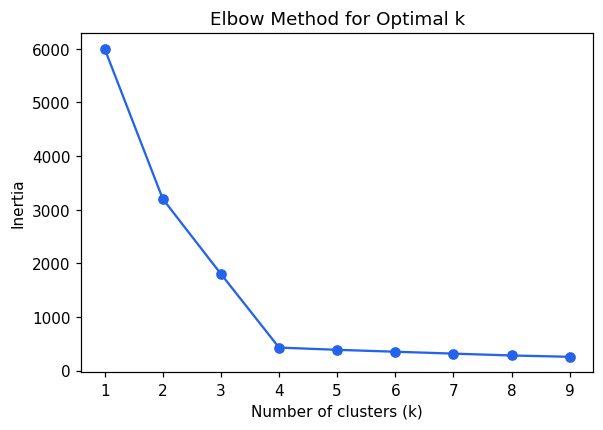

In [4]:
inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, "o-", color="#2563eb")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


## 5. Fit final model (k=4)

In [5]:
k_final = 4
model = KMeans(n_clusters=k_final, n_init=10, random_state=42)
labels = model.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, labels)
print(f"Chosen k = {k_final}")
print(f"Silhouette Score: {sil:.4f}")

centers_orig = scaler.inverse_transform(model.cluster_centers_)
for i, c in enumerate(centers_orig):
    print(f"  Cluster {i}: income≈{c[0]:.1f}k, spending_score≈{c[1]:.1f} "
          f"({np.sum(labels == i)} customers)")


Chosen k = 4
Silhouette Score: 0.7310
  Cluster 0: income≈25.1k, spending_score≈80.2 (750 customers)
  Cluster 1: income≈80.0k, spending_score≈19.3 (751 customers)
  Cluster 2: income≈24.8k, spending_score≈20.9 (749 customers)
  Cluster 3: income≈80.1k, spending_score≈79.4 (750 customers)


## 6. Visualize the segments

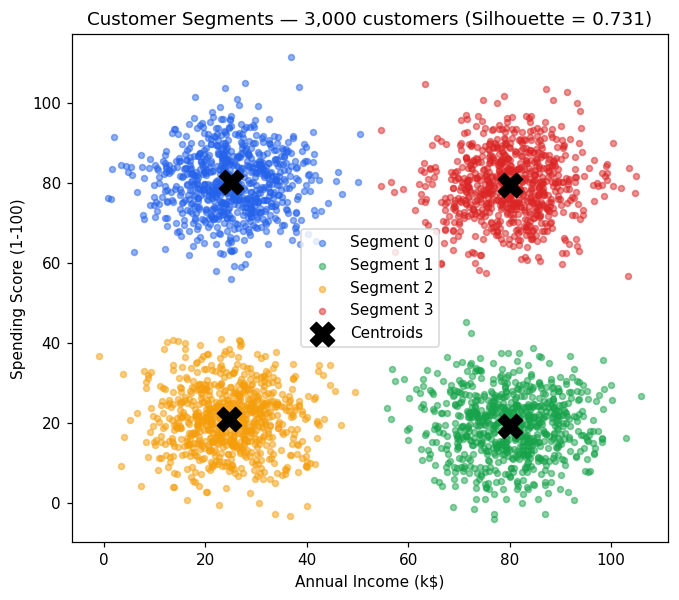

In [6]:
colors = ["#2563eb", "#16a34a", "#f59e0b", "#dc2626"]
plt.figure(figsize=(7, 6))
for i in range(k_final):
    mask = labels == i
    plt.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.5,
                color=colors[i % len(colors)], label=f"Segment {i}")
plt.scatter(centers_orig[:, 0], centers_orig[:, 1], marker="X", s=250,
            color="black", label="Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"Customer Segments — 3,000 customers (Silhouette = {sil:.3f})")
plt.legend()
plt.show()


## Summary

Even scaled up to 3,000 customers, K-Means cleanly recovers the same 4 segments with a high silhouette score (>0.7), confirming the clusters are well-separated and stable.